In [36]:
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
mnist = fetch_openml("mnist_784")

In [3]:
X,y = mnist["data"] , mnist["target"]

In [4]:
X = X.to_numpy()

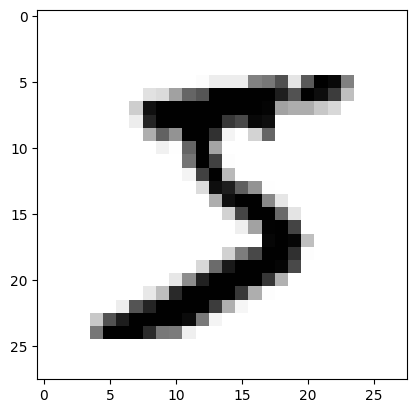

In [5]:
plt.imshow(X[0].reshape(28,28),cmap="binary")

In [6]:
x_train, x_test = X[:60000], X[60000:]
x_train, x_test = x_train/255, x_test/255

In [7]:
y_train, y_test = y[:60000], y[60000:]

In [10]:
y_train  = y_train.astype(np.int8)
y_test   = y_test.astype(np.int8)

In [11]:
import numpy as np

In [12]:
shuffle_index = np.random.permutation(60000)

In [13]:
x_train,y_train = x_train[shuffle_index], y_train[shuffle_index]

In [39]:
?XGBClassifier

Init signature:
XGBClassifier(
    *,
    objective: Union[str, xgboost.sklearn._SklObjWProto, Callable[[Any, Any], Tuple[numpy.ndarray, numpy.ndarray]], NoneType] = 'binary:logistic',
    **kwargs: Any,
) -> None
Docstring:     
Implementation of the scikit-learn API for XGBoost classification.
See :doc:`/python/sklearn_estimator` for more information.

Parameters
----------

    n_estimators : Optional[int]
        Number of boosting rounds.

    max_depth :  typing.Optional[int]

        Maximum tree depth for base learners.

    max_leaves : typing.Optional[int]

        Maximum number of leaves; 0 indicates no limit.

    max_bin : typing.Optional[int]

        If using histogram-based algorithm, maximum number of bins per feature

    grow_policy : typing.Optional[str]

        Tree growing policy.

        - depthwise: Favors splitting at nodes closest to the node,
        - lossguide: Favors splitting at nodes with highest loss change.

    learning_rate : typing.Optional[float

In [45]:
from xgboost import XGBClassifier

model = XGBClassifier(
    random_state = 42,
    n_jobs = -1,
    n_estimator = 1500,
    max_leaves = 256,
    learning_rate = 0.03,
    predictor="gpu_predictor",
    grow_policy="lossguide"
)

model.fit(x_train, y_train)

C:\Users\zisha\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [04:41:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimator", "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [22]:
import joblib

In [23]:
joblib.dump(model,"XGBoost_gpu_based.pkl")

['XGBoost_gpu_based.pkl']

In [46]:
model.predict(x_test[[0]])

array([7])

In [47]:
y_test.iloc[0]

np.int8(7)

In [48]:
model.predict(pd.DataFrame([{'pixel_0': 0.0, 'pixel_1': 0.0, 'pixel_2': 0.0, 'pixel_3': 0.0, 'pixel_4': 0.0, 'pixel_5': 0.0, 'pixel_6': 0.0, 'pixel_7': 0.0, 'pixel_8': 0.0, 'pixel_9': 0.0, 'pixel_10': 0.0, 'pixel_11': 0.0, 'pixel_12': 0.0, 'pixel_13': 0.0, 'pixel_14': 0.0, 'pixel_15': 0.0, 'pixel_16': 0.0, 'pixel_17': 0.0, 'pixel_18': 0.0, 'pixel_19': 0.0, 'pixel_20': 0.0, 'pixel_21': 0.0, 'pixel_22': 0.0, 'pixel_23': 0.0, 'pixel_24': 18798.0, 'pixel_25': 18798.0, 'pixel_26': 0.0, 'pixel_27': 0.0, 'pixel_28': 0.0, 'pixel_29': 0.0, 'pixel_30': 0.0, 'pixel_31': 0.0, 'pixel_32': 0.0, 'pixel_33': 0.0, 'pixel_34': 0.0, 'pixel_35': 0.0, 'pixel_36': 0.0, 'pixel_37': 0.0, 'pixel_38': 0.0, 'pixel_39': 0.0, 'pixel_40': 0.0, 'pixel_41': 0.0, 'pixel_42': 0.0, 'pixel_43': 0.0, 'pixel_44': 0.0, 'pixel_45': 0.0, 'pixel_46': 0.0, 'pixel_47': 56394.0, 'pixel_48': 65793.0, 'pixel_49': 65793.0, 'pixel_50': 65793.0, 'pixel_51': 65793.0, 'pixel_52': 65793.0, 'pixel_53': 65793.0, 'pixel_54': 65793.0, 'pixel_55': 0.0, 'pixel_56': 0.0, 'pixel_57': 0.0, 'pixel_58': 0.0, 'pixel_59': 0.0, 'pixel_60': 0.0, 'pixel_61': 0.0, 'pixel_62': 0.0, 'pixel_63': 0.0, 'pixel_64': 0.0, 'pixel_65': 0.0, 'pixel_66': 0.0, 'pixel_67': 0.0, 'pixel_68': 0.0, 'pixel_69': 0.0, 'pixel_70': 0.0, 'pixel_71': 0.0, 'pixel_72': 65793.0, 'pixel_73': 65793.0, 'pixel_74': 65793.0, 'pixel_75': 65793.0, 'pixel_76': 65793.0, 'pixel_77': 65793.0, 'pixel_78': 0.0, 'pixel_79': 0.0, 'pixel_80': 0.0, 'pixel_81': 0.0, 'pixel_82': 0.0, 'pixel_83': 0.0, 'pixel_84': 0.0, 'pixel_85': 0.0, 'pixel_86': 0.0, 'pixel_87': 0.0, 'pixel_88': 0.0, 'pixel_89': 0.0, 'pixel_90': 0.0, 'pixel_91': 0.0, 'pixel_92': 0.0, 'pixel_93': 0.0, 'pixel_94': 0.0, 'pixel_95': 0.0, 'pixel_96': 0.0, 'pixel_97': 0.0, 'pixel_98': 65793.0, 'pixel_99': 65793.0, 'pixel_100': 65793.0, 'pixel_101': 65793.0, 'pixel_102': 0.0, 'pixel_103': 0.0, 'pixel_104': 0.0, 'pixel_105': 0.0, 'pixel_106': 0.0, 'pixel_107': 0.0, 'pixel_108': 0.0, 'pixel_109': 0.0, 'pixel_110': 0.0, 'pixel_111': 0.0, 'pixel_112': 0.0, 'pixel_113': 0.0, 'pixel_114': 0.0, 'pixel_115': 0.0, 'pixel_116': 0.0, 'pixel_117': 0.0, 'pixel_118': 0.0, 'pixel_119': 0.0, 'pixel_120': 0.0, 'pixel_121': 0.0, 'pixel_122': 0.0, 'pixel_123': 28197.0, 'pixel_124': 65793.0, 'pixel_125': 65793.0, 'pixel_126': 65793.0, 'pixel_127': 24168.85546875, 'pixel_128': 0.0, 'pixel_129': 0.0, 'pixel_130': 0.0, 'pixel_131': 0.0, 'pixel_132': 0.0, 'pixel_133': 0.0, 'pixel_134': 0.0, 'pixel_135': 0.0, 'pixel_136': 0.0, 'pixel_137': 0.0, 'pixel_138': 0.0, 'pixel_139': 0.0, 'pixel_140': 0.0, 'pixel_141': 0.0, 'pixel_142': 0.0, 'pixel_143': 0.0, 'pixel_144': 0.0, 'pixel_145': 0.0, 'pixel_146': 0.0, 'pixel_147': 0.0, 'pixel_148': 0.0, 'pixel_149': 0.0, 'pixel_150': 65793.0, 'pixel_151': 65793.0, 'pixel_152': 65793.0, 'pixel_153': 0.0, 'pixel_154': 0.0, 'pixel_155': 0.0, 'pixel_156': 0.0, 'pixel_157': 0.0, 'pixel_158': 0.0, 'pixel_159': 0.0, 'pixel_160': 0.0, 'pixel_161': 0.0, 'pixel_162': 0.0, 'pixel_163': 0.0, 'pixel_164': 0.0, 'pixel_165': 0.0, 'pixel_166': 0.0, 'pixel_167': 0.0, 'pixel_168': 0.0, 'pixel_169': 0.0, 'pixel_170': 0.0, 'pixel_171': 0.0, 'pixel_172': 0.0, 'pixel_173': 0.0, 'pixel_174': 0.0, 'pixel_175': 0.0, 'pixel_176': 49680.4296875, 'pixel_177': 65793.0, 'pixel_178': 65793.0, 'pixel_179': 65793.0, 'pixel_180': 0.0, 'pixel_181': 0.0, 'pixel_182': 0.0, 'pixel_183': 0.0, 'pixel_184': 0.0, 'pixel_185': 0.0, 'pixel_186': 0.0, 'pixel_187': 0.0, 'pixel_188': 0.0, 'pixel_189': 0.0, 'pixel_190': 0.0, 'pixel_191': 0.0, 'pixel_192': 0.0, 'pixel_193': 0.0, 'pixel_194': 0.0, 'pixel_195': 0.0, 'pixel_196': 0.0, 'pixel_197': 0.0, 'pixel_198': 0.0, 'pixel_199': 0.0, 'pixel_200': 0.0, 'pixel_201': 0.0, 'pixel_202': 0.0, 'pixel_203': 52365.859375, 'pixel_204': 65793.0, 'pixel_205': 65793.0, 'pixel_206': 0.0, 'pixel_207': 0.0, 'pixel_208': 0.0, 'pixel_209': 0.0, 'pixel_210': 0.0, 'pixel_211': 0.0, 'pixel_212': 0.0, 'pixel_213': 0.0, 'pixel_214': 0.0, 'pixel_215': 0.0, 'pixel_216': 0.0, 'pixel_217': 0.0, 'pixel_218': 0.0, 'pixel_219': 0.0, 'pixel_220': 0.0, 'pixel_221': 0.0, 'pixel_222': 0.0, 'pixel_223': 0.0, 'pixel_224': 0.0, 'pixel_225': 0.0, 'pixel_226': 0.0, 'pixel_227': 0.0, 'pixel_228': 0.0, 'pixel_229': 0.0, 'pixel_230': 65793.0, 'pixel_231': 65793.0, 'pixel_232': 65793.0, 'pixel_233': 0.0, 'pixel_234': 0.0, 'pixel_235': 0.0, 'pixel_236': 0.0, 'pixel_237': 0.0, 'pixel_238': 0.0, 'pixel_239': 0.0, 'pixel_240': 0.0, 'pixel_241': 0.0, 'pixel_242': 0.0, 'pixel_243': 0.0, 'pixel_244': 0.0, 'pixel_245': 0.0, 'pixel_246': 0.0, 'pixel_247': 0.0, 'pixel_248': 0.0, 'pixel_249': 0.0, 'pixel_250': 0.0, 'pixel_251': 0.0, 'pixel_252': 0.0, 'pixel_253': 0.0, 'pixel_254': 0.0, 'pixel_255': 0.0, 'pixel_256': 0.0, 'pixel_257': 60422.140625, 'pixel_258': 65793.0, 'pixel_259': 65793.0, 'pixel_260': 0.0, 'pixel_261': 0.0, 'pixel_262': 0.0, 'pixel_263': 0.0, 'pixel_264': 0.0, 'pixel_265': 0.0, 'pixel_266': 0.0, 'pixel_267': 0.0, 'pixel_268': 0.0, 'pixel_269': 0.0, 'pixel_270': 0.0, 'pixel_271': 0.0, 'pixel_272': 0.0, 'pixel_273': 0.0, 'pixel_274': 0.0, 'pixel_275': 0.0, 'pixel_276': 0.0, 'pixel_277': 0.0, 'pixel_278': 0.0, 'pixel_279': 0.0, 'pixel_280': 0.0, 'pixel_281': 0.0, 'pixel_282': 0.0, 'pixel_283': 0.0, 'pixel_284': 65793.0, 'pixel_285': 65793.0, 'pixel_286': 65793.0, 'pixel_287': 0.0, 'pixel_288': 0.0, 'pixel_289': 0.0, 'pixel_290': 0.0, 'pixel_291': 0.0, 'pixel_292': 0.0, 'pixel_293': 0.0, 'pixel_294': 0.0, 'pixel_295': 0.0, 'pixel_296': 0.0, 'pixel_297': 0.0, 'pixel_298': 0.0, 'pixel_299': 0.0, 'pixel_300': 0.0, 'pixel_301': 0.0, 'pixel_302': 0.0, 'pixel_303': 0.0, 'pixel_304': 0.0, 'pixel_305': 0.0, 'pixel_306': 0.0, 'pixel_307': 0.0, 'pixel_308': 0.0, 'pixel_309': 0.0, 'pixel_310': 0.0, 'pixel_311': 0.0, 'pixel_312': 65793.0, 'pixel_313': 65793.0, 'pixel_314': 0.0, 'pixel_315': 0.0, 'pixel_316': 0.0, 'pixel_317': 0.0, 'pixel_318': 0.0, 'pixel_319': 0.0, 'pixel_320': 0.0, 'pixel_321': 0.0, 'pixel_322': 0.0, 'pixel_323': 0.0, 'pixel_324': 0.0, 'pixel_325': 0.0, 'pixel_326': 0.0, 'pixel_327': 0.0, 'pixel_328': 0.0, 'pixel_329': 0.0, 'pixel_330': 0.0, 'pixel_331': 0.0, 'pixel_332': 0.0, 'pixel_333': 0.0, 'pixel_334': 0.0, 'pixel_335': 0.0, 'pixel_336': 0.0, 'pixel_337': 0.0, 'pixel_338': 0.0, 'pixel_339': 65793.0, 'pixel_340': 65793.0, 'pixel_341': 1342.7142333984375, 'pixel_342': 0.0, 'pixel_343': 0.0, 'pixel_344': 0.0, 'pixel_345': 0.0, 'pixel_346': 0.0, 'pixel_347': 0.0, 'pixel_348': 0.0, 'pixel_349': 0.0, 'pixel_350': 0.0, 'pixel_351': 0.0, 'pixel_352': 0.0, 'pixel_353': 0.0, 'pixel_354': 0.0, 'pixel_355': 0.0, 'pixel_356': 0.0, 'pixel_357': 0.0, 'pixel_358': 0.0, 'pixel_359': 0.0, 'pixel_360': 0.0, 'pixel_361': 0.0, 'pixel_362': 0.0, 'pixel_363': 0.0, 'pixel_364': 0.0, 'pixel_365': 0.0, 'pixel_366': 65793.0, 'pixel_367': 65793.0, 'pixel_368': 65793.0, 'pixel_369': 0.0, 'pixel_370': 0.0, 'pixel_371': 0.0, 'pixel_372': 0.0, 'pixel_373': 0.0, 'pixel_374': 0.0, 'pixel_375': 0.0, 'pixel_376': 0.0, 'pixel_377': 0.0, 'pixel_378': 0.0, 'pixel_379': 0.0, 'pixel_380': 0.0, 'pixel_381': 0.0, 'pixel_382': 0.0, 'pixel_383': 0.0, 'pixel_384': 0.0, 'pixel_385': 0.0, 'pixel_386': 0.0, 'pixel_387': 0.0, 'pixel_388': 0.0, 'pixel_389': 0.0, 'pixel_390': 0.0, 'pixel_391': 0.0, 'pixel_392': 0.0, 'pixel_393': 9399.0, 'pixel_394': 65793.0, 'pixel_395': 65793.0, 'pixel_396': 0.0, 'pixel_397': 0.0, 'pixel_398': 0.0, 'pixel_399': 0.0, 'pixel_400': 0.0, 'pixel_401': 0.0, 'pixel_402': 0.0, 'pixel_403': 0.0, 'pixel_404': 0.0, 'pixel_405': 0.0, 'pixel_406': 0.0, 'pixel_407': 0.0, 'pixel_408': 0.0, 'pixel_409': 0.0, 'pixel_410': 0.0, 'pixel_411': 0.0, 'pixel_412': 0.0, 'pixel_413': 0.0, 'pixel_414': 0.0, 'pixel_415': 0.0, 'pixel_416': 0.0, 'pixel_417': 0.0, 'pixel_418': 0.0, 'pixel_419': 0.0, 'pixel_420': 0.0, 'pixel_421': 9399.0, 'pixel_422': 65793.0, 'pixel_423': 65793.0, 'pixel_424': 0.0, 'pixel_425': 0.0, 'pixel_426': 0.0, 'pixel_427': 0.0, 'pixel_428': 56394.0, 'pixel_429': 65793.0, 'pixel_430': 65793.0, 'pixel_431': 65793.0, 'pixel_432': 65793.0, 'pixel_433': 65793.0, 'pixel_434': 65793.0, 'pixel_435': 65793.0, 'pixel_436': 65793.0, 'pixel_437': 65793.0, 'pixel_438': 65793.0, 'pixel_439': 65793.0, 'pixel_440': 65793.0, 'pixel_441': 0.0, 'pixel_442': 0.0, 'pixel_443': 0.0, 'pixel_444': 0.0, 'pixel_445': 0.0, 'pixel_446': 0.0, 'pixel_447': 0.0, 'pixel_448': 0.0, 'pixel_449': 65793.0, 'pixel_450': 65793.0, 'pixel_451': 65793.0, 'pixel_452': 0.0, 'pixel_453': 65793.0, 'pixel_454': 65793.0, 'pixel_455': 65793.0, 'pixel_456': 65793.0, 'pixel_457': 65793.0, 'pixel_458': 65793.0, 'pixel_459': 21483.427734375, 'pixel_460': 0.0, 'pixel_461': 0.0, 'pixel_462': 0.0, 'pixel_463': 0.0, 'pixel_464': 0.0, 'pixel_465': 0.0, 'pixel_466': 65793.0, 'pixel_467': 65793.0, 'pixel_468': 65793.0, 'pixel_469': 65793.0, 'pixel_470': 65793.0, 'pixel_471': 12084.427734375, 'pixel_472': 0.0, 'pixel_473': 0.0, 'pixel_474': 0.0, 'pixel_475': 0.0, 'pixel_476': 0.0, 'pixel_477': 65793.0, 'pixel_478': 65793.0, 'pixel_479': 65793.0, 'pixel_480': 65793.0, 'pixel_481': 65793.0, 'pixel_482': 65793.0, 'pixel_483': 0.0, 'pixel_484': 0.0, 'pixel_485': 0.0, 'pixel_486': 0.0, 'pixel_487': 0.0, 'pixel_488': 0.0, 'pixel_489': 0.0, 'pixel_490': 0.0, 'pixel_491': 0.0, 'pixel_492': 0.0, 'pixel_493': 0.0, 'pixel_494': 0.0, 'pixel_495': 0.0, 'pixel_496': 0.0, 'pixel_497': 65793.0, 'pixel_498': 65793.0, 'pixel_499': 65793.0, 'pixel_500': 65793.0, 'pixel_501': 0.0, 'pixel_502': 0.0, 'pixel_503': 0.0, 'pixel_504': 0.0, 'pixel_505': 65793.0, 'pixel_506': 65793.0, 'pixel_507': 65793.0, 'pixel_508': 65793.0, 'pixel_509': 65793.0, 'pixel_510': 0.0, 'pixel_511': 0.0, 'pixel_512': 0.0, 'pixel_513': 0.0, 'pixel_514': 0.0, 'pixel_515': 0.0, 'pixel_516': 0.0, 'pixel_517': 0.0, 'pixel_518': 0.0, 'pixel_519': 0.0, 'pixel_520': 0.0, 'pixel_521': 0.0, 'pixel_522': 0.0, 'pixel_523': 0.0, 'pixel_524': 0.0, 'pixel_525': 0.0, 'pixel_526': 4028.142578125, 'pixel_527': 65793.0, 'pixel_528': 65793.0, 'pixel_529': 65793.0, 'pixel_530': 0.0, 'pixel_531': 0.0, 'pixel_532': 0.0, 'pixel_533': 65793.0, 'pixel_534': 65793.0, 'pixel_535': 65793.0, 'pixel_536': 0.0, 'pixel_537': 0.0, 'pixel_538': 0.0, 'pixel_539': 0.0, 'pixel_540': 0.0, 'pixel_541': 0.0, 'pixel_542': 0.0, 'pixel_543': 0.0, 'pixel_544': 0.0, 'pixel_545': 0.0, 'pixel_546': 0.0, 'pixel_547': 0.0, 'pixel_548': 0.0, 'pixel_549': 0.0, 'pixel_550': 0.0, 'pixel_551': 0.0, 'pixel_552': 0.0, 'pixel_553': 0.0, 'pixel_554': 0.0, 'pixel_555': 0.0, 'pixel_556': 65793.0, 'pixel_557': 65793.0, 'pixel_558': 9398.9990234375, 'pixel_559': 0.0, 'pixel_560': 0.0, 'pixel_561': 65793.0, 'pixel_562': 65793.0, 'pixel_563': 65793.0, 'pixel_564': 0.0, 'pixel_565': 0.0, 'pixel_566': 0.0, 'pixel_567': 0.0, 'pixel_568': 0.0, 'pixel_569': 0.0, 'pixel_570': 0.0, 'pixel_571': 0.0, 'pixel_572': 0.0, 'pixel_573': 0.0, 'pixel_574': 0.0, 'pixel_575': 0.0, 'pixel_576': 0.0, 'pixel_577': 0.0, 'pixel_578': 0.0, 'pixel_579': 0.0, 'pixel_580': 0.0, 'pixel_581': 0.0, 'pixel_582': 0.0, 'pixel_583': 0.0, 'pixel_584': 65793.0, 'pixel_585': 65793.0, 'pixel_586': 9398.9990234375, 'pixel_587': 0.0, 'pixel_588': 0.0, 'pixel_589': 9399.0, 'pixel_590': 65793.0, 'pixel_591': 65793.0, 'pixel_592': 0.0, 'pixel_593': 0.0, 'pixel_594': 0.0, 'pixel_595': 0.0, 'pixel_596': 0.0, 'pixel_597': 0.0, 'pixel_598': 0.0, 'pixel_599': 0.0, 'pixel_600': 0.0, 'pixel_601': 0.0, 'pixel_602': 0.0, 'pixel_603': 0.0, 'pixel_604': 0.0, 'pixel_605': 0.0, 'pixel_606': 0.0, 'pixel_607': 0.0, 'pixel_608': 0.0, 'pixel_609': 0.0, 'pixel_610': 0.0, 'pixel_611': 0.0, 'pixel_612': 65793.0, 'pixel_613': 65793.0, 'pixel_614': 9398.9990234375, 'pixel_615': 0.0, 'pixel_616': 0.0, 'pixel_617': 0.0, 'pixel_618': 41624.140625, 'pixel_619': 65793.0, 'pixel_620': 65793.0, 'pixel_621': 0.0, 'pixel_622': 0.0, 'pixel_623': 0.0, 'pixel_624': 0.0, 'pixel_625': 0.0, 'pixel_626': 0.0, 'pixel_627': 0.0, 'pixel_628': 0.0, 'pixel_629': 0.0, 'pixel_630': 0.0, 'pixel_631': 0.0, 'pixel_632': 0.0, 'pixel_633': 0.0, 'pixel_634': 0.0, 'pixel_635': 0.0, 'pixel_636': 0.0, 'pixel_637': 0.0, 'pixel_638': 0.0, 'pixel_639': 65793.0, 'pixel_640': 65793.0, 'pixel_641': 65793.0, 'pixel_642': 0.0, 'pixel_643': 0.0, 'pixel_644': 0.0, 'pixel_645': 0.0, 'pixel_646': 0.0, 'pixel_647': 37596.0, 'pixel_648': 65793.0, 'pixel_649': 65793.0, 'pixel_650': 20140.712890625, 'pixel_651': 0.0, 'pixel_652': 0.0, 'pixel_653': 0.0, 'pixel_654': 0.0, 'pixel_655': 0.0, 'pixel_656': 0.0, 'pixel_657': 0.0, 'pixel_658': 0.0, 'pixel_659': 0.0, 'pixel_660': 0.0, 'pixel_661': 0.0, 'pixel_662': 0.0, 'pixel_663': 0.0, 'pixel_664': 0.0, 'pixel_665': 0.0, 'pixel_666': 33567.859375, 'pixel_667': 65793.0, 'pixel_668': 65793.0, 'pixel_669': 21483.427734375, 'pixel_670': 0.0, 'pixel_671': 0.0, 'pixel_672': 0.0, 'pixel_673': 0.0, 'pixel_674': 0.0, 'pixel_675': 0.0, 'pixel_676': 0.0, 'pixel_677': 65793.0, 'pixel_678': 65793.0, 'pixel_679': 65793.0, 'pixel_680': 0.0, 'pixel_681': 0.0, 'pixel_682': 0.0, 'pixel_683': 0.0, 'pixel_684': 0.0, 'pixel_685': 0.0, 'pixel_686': 0.0, 'pixel_687': 0.0, 'pixel_688': 0.0, 'pixel_689': 0.0, 'pixel_690': 0.0, 'pixel_691': 0.0, 'pixel_692': 0.0, 'pixel_693': 65793.0, 'pixel_694': 65793.0, 'pixel_695': 65793.0, 'pixel_696': 65793.0, 'pixel_697': 0.0, 'pixel_698': 0.0, 'pixel_699': 0.0, 'pixel_700': 0.0, 'pixel_701': 0.0, 'pixel_702': 0.0, 'pixel_703': 0.0, 'pixel_704': 0.0, 'pixel_705': 0.0, 'pixel_706': 8056.28515625, 'pixel_707': 65793.0, 'pixel_708': 65793.0, 'pixel_709': 65793.0, 'pixel_710': 65793.0, 'pixel_711': 21483.4296875, 'pixel_712': 0.0, 'pixel_713': 0.0, 'pixel_714': 0.0, 'pixel_715': 0.0, 'pixel_716': 0.0, 'pixel_717': 0.0, 'pixel_718': 0.0, 'pixel_719': 65793.0, 'pixel_720': 65793.0, 'pixel_721': 65793.0, 'pixel_722': 65793.0, 'pixel_723': 0.0, 'pixel_724': 0.0, 'pixel_725': 0.0, 'pixel_726': 0.0, 'pixel_727': 0.0, 'pixel_728': 0.0, 'pixel_729': 0.0, 'pixel_730': 0.0, 'pixel_731': 0.0, 'pixel_732': 0.0, 'pixel_733': 0.0, 'pixel_734': 0.0, 'pixel_735': 0.0, 'pixel_736': 0.0, 'pixel_737': 56394.0, 'pixel_738': 65793.0, 'pixel_739': 65793.0, 'pixel_740': 65793.0, 'pixel_741': 65793.0, 'pixel_742': 65793.0, 'pixel_743': 65793.0, 'pixel_744': 65793.0, 'pixel_745': 65793.0, 'pixel_746': 65793.0, 'pixel_747': 65793.0, 'pixel_748': 40281.42578125, 'pixel_749': 0.0, 'pixel_750': 0.0, 'pixel_751': 0.0, 'pixel_752': 0.0, 'pixel_753': 0.0, 'pixel_754': 0.0, 'pixel_755': 0.0, 'pixel_756': 0.0, 'pixel_757': 0.0, 'pixel_758': 0.0, 'pixel_759': 0.0, 'pixel_760': 0.0, 'pixel_761': 0.0, 'pixel_762': 0.0, 'pixel_763': 0.0, 'pixel_764': 0.0, 'pixel_765': 0.0, 'pixel_766': 0.0, 'pixel_767': 0.0, 'pixel_768': 0.0, 'pixel_769': 18797.998046875, 'pixel_770': 13427.142578125, 'pixel_771': 0.0, 'pixel_772': 18797.998046875, 'pixel_773': 0.0, 'pixel_774': 0.0, 'pixel_775': 0.0, 'pixel_776': 0.0, 'pixel_777': 0.0, 'pixel_778': 0.0, 'pixel_779': 0.0, 'pixel_780': 0.0, 'pixel_781': 0.0, 'pixel_782': 0.0, 'pixel_783': 0.0}]))

array([7])